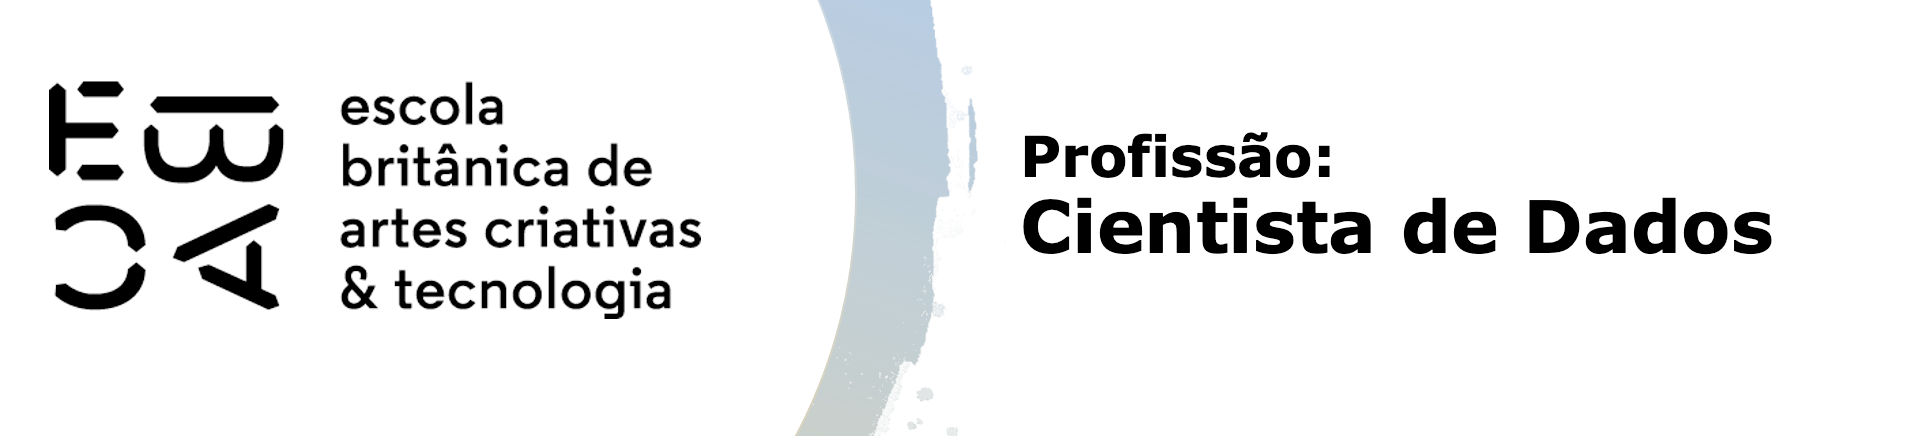

# Task - Hierarchical grouping

In this exercise we will use the base [online shoppers purchase intention](https://archive.ics.uci.edu/ml/datasets/Online+Shoppers+Purchasing+Intention+Dataset) de Sakar, C.O., Polat, S.O., Katircioglu, M. et al. Neural Comput & Applic (2018). [Web Link](https://doi.org/10.1007/s00521-018-3523-0).

The database contains records of 12330 page access sessions, each session being from a single user over a period of 12 months, so that we can later study the relationship between page design and the customer profile - "Do customers with different navigation type have different purchasing propensity?" 

Our objective now is to group portal access sessions considering access behavior and date information, such as proximity to a special date, weekend and month.

|Variable                | Description          | 
|------------------------|:-------------------| 
|Administrative          | Number of accesses to administrative pages | 
|Administrative_Duration | Access time on administrative pages | 
|Informational           | Number of accesses on informational pages | 
|Informational_Duration  | Access time on informational pages  | 
|ProductRelated          | Number of hits on product pages | 
|ProductRelated_Duration | Access time on product pages | 
|BounceRates             | Percentage of visitors who enter the site and leave without triggering other *requests* during the session  | 
|ExitRates               | Sum of times the page is last viewed in a session divided by total views | 
|PageValues              | Represents the average value of a web page a user visited before completing an e-commerce transaction | 
|SpecialDay              | Indicates proximity to a festive date (Mother's Day, etc.) | 
|Month                   | Month | 
|OperatingSystems        | Visitor's operational system | 
|Browser                 | Visitor's browser | 
|Region                  | Region | 
|TrafficType             | Type of traffic | 
|VisitorType             | Visitor type: new or returning | 
|Weekend                 | Indicates weekend | 
|**Revenue**             | **Indicates whether a purchase was made or not** |

\* variables calculated by google analytics

In [1]:
########## PYTHON PATH EXTENSION ##########

import sys
sys.path.append('C:/Users/User/AppData/Local/Programs/Python/Python311/Lib/site-packages')

########## IMPORTS BLOCK ##########

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from gower import gower_matrix
from sklearn.decomposition import PCA
from sklearn.neighbors import DistanceMetric
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import EmpiricalCovariance
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist, cdist, squareform

########## FILE OPENING ##########

df = pd.read_csv('online_shoppers_intention.csv')
print(df.Revenue.value_counts(dropna=False))

False    10422
True      1908
Name: Revenue, dtype: int64


> Around 15.5 % of accesses were registered as a purchase, thus converted into 'Revenue'.

## Descriptive analysis

Carry out a descriptive analysis of the scope variables.

- Check the distribution of these variables
- See if there are *missing* values and if so, decide what to do
- Do some more processing on the variables if you think it’s relevant

In [2]:
########## DATA SUMMARY ##########

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

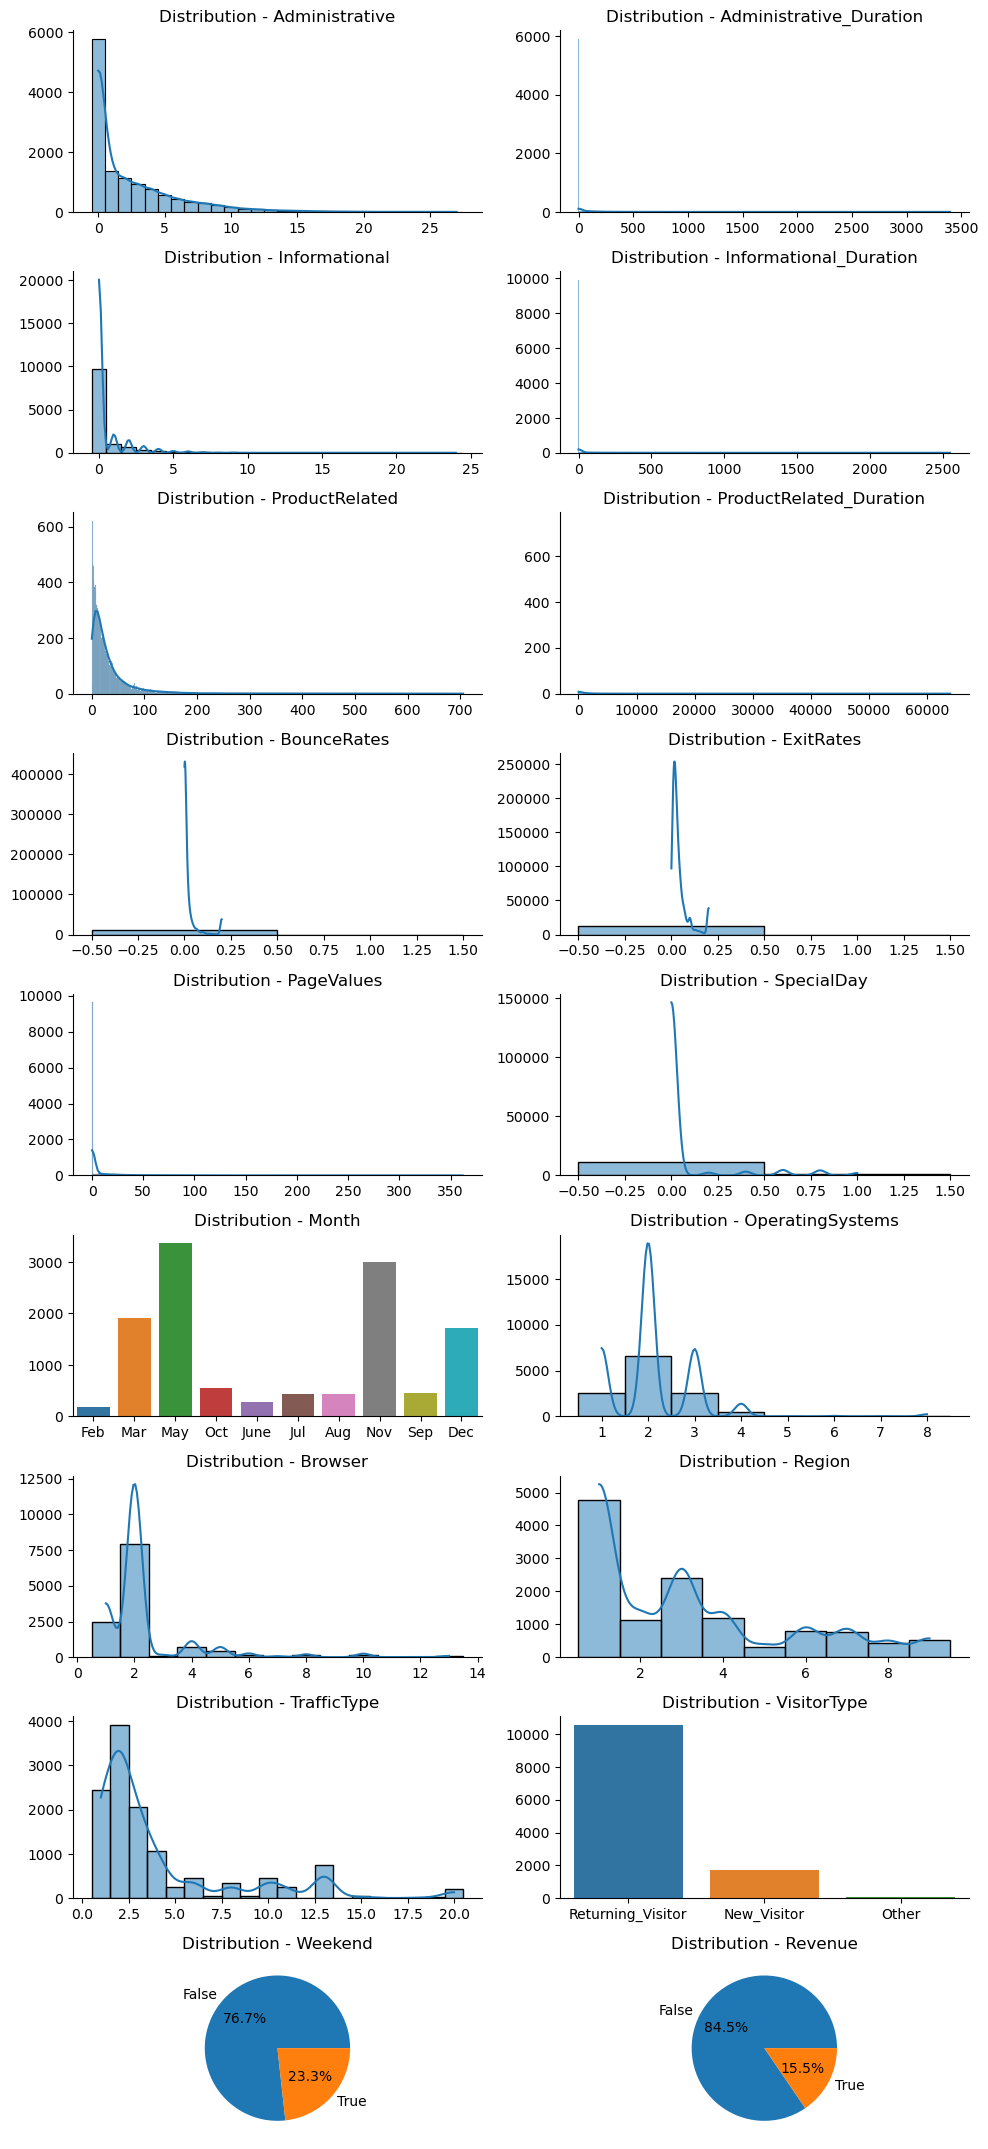

In [3]:
########## VISUALIZATION OF DISTRIBUTIONS ##########

plt.figure(figsize=(10, 24))

for i, col in enumerate(df.columns):
    if df[col].dtype == 'object':
        plt.subplot(len(df.columns)//2 + 1, 2, i+1)
        sns.countplot(data=df, x=col)
        plt.title(f'Distribution - {col}')
        plt.xlabel('')
        plt.ylabel('')
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)
    elif np.issubdtype(df[col].dtype, np.number):
        plt.subplot(len(df.columns)//2 + 1, 2, i+1)
        sns.histplot(df[col], discrete=True, kde=True)
        plt.title(f'Distribution - {col}')
        plt.xlabel('')
        plt.ylabel('')
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)
    elif df[col].dtype == 'bool':
        plt.subplot(len(df.columns)//2 + 1, 2, i+1)
        df[col].value_counts().plot(kind='pie', autopct='%1.1f%%')
        plt.title(f'Distribution - {col}')
        plt.xlabel('')
        plt.ylabel('')
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [4]:
########## NUMERICAL DISTRIBUITIONS ##########

df.describe().round(2)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00
mean,2.32,80.82,0.50,34.47,31.73,1194.75,0.02,0.04,5.89,0.06,2.12,2.36,3.15,4.07
std,3.32,176.78,1.27,140.75,44.48,1913.67,0.05,0.05,18.57,0.20,0.91,1.72,2.40,4.03
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00
25%,0.00,0.00,0.00,0.00,7.00,184.14,0.00,0.01,0.00,0.00,2.00,2.00,1.00,2.00
50%,1.00,7.50,0.00,0.00,18.00,598.94,0.00,0.03,0.00,0.00,2.00,2.00,3.00,2.00
75%,4.00,93.26,0.00,0.00,38.00,1464.16,0.02,0.05,0.00,0.00,3.00,2.00,4.00,4.00
max,27.00,3398.75,24.00,2549.38,705.00,63973.52,0.20,0.20,361.76,1.00,8.00,13.00,9.00,20.00


In [5]:
########## MISSINGS RESEARCH ##########

df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

> Confirmation about missing values in any variable. The data set is fully operational to analysis.

## Grouping variables

List the variables you will want to use. This is an important project activity, and we typically do not receive it ready-made. There is no ready or correct answer, but only criteria and your decision. The criteria are as follows:

- Select variables for grouping that describe the navigation pattern in the session.
- Select variables that indicate the date characteristic.
- Don't forget that you will need to carry out special treatment for qualitative variables.
- Properly handle missing values.

#### Session navigation pattern:

- Administrative
- Administrative_Duration
- Informational
- Informational_Duration
- ProductRelated
- ProductRelated_Duration
- TrafficType
- PageValues
- Region
- Browser
- Weekend

#### Date characteristics:

- Month
- SpecialDay
- Weekend

#### Target variable:

- Revenue

In [6]:
########## VARIABLE ASSIGNMENT ##########

variables = df.columns.values[:-1]

numeric_variables = df.select_dtypes(include=['number']).columns.tolist()

time_caracteristics = ['Month', 'SpecialDay', 'Weekend']

########## DATA PREPROCESSING - STANDARDIZATION, DUMMIES & CATEGORIZATION ##########

scaler = StandardScaler()
df_std = pd.DataFrame(StandardScaler().fit_transform(df[numeric_variables]), columns = df[numeric_variables].columns)
df_std[time_caracteristics] = df[time_caracteristics]

df_encoded = pd.get_dummies(df_std, columns=time_caracteristics, drop_first=True)
df_encoded.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,OperatingSystems,...,Month_May,Month_Nov,Month_Oct,Month_Sep,SpecialDay_0.2,SpecialDay_0.4,SpecialDay_0.6,SpecialDay_0.8,SpecialDay_1.0,Weekend_True
0,-0.696993,-0.457191,-0.396478,-0.244931,-0.691003,-0.624348,3.667189,3.229316,-0.317178,-1.233426,...,0,0,0,0,0,0,0,0,0,0
1,-0.696993,-0.457191,-0.396478,-0.244931,-0.668518,-0.590903,-0.457683,1.171473,-0.317178,-0.136078,...,0,0,0,0,0,0,0,0,0,0
2,-0.696993,-0.457191,-0.396478,-0.244931,-0.691003,-0.624348,3.667189,3.229316,-0.317178,2.058618,...,0,0,0,0,0,0,0,0,0,0
3,-0.696993,-0.457191,-0.396478,-0.244931,-0.668518,-0.622954,0.573535,1.994610,-0.317178,0.961270,...,0,0,0,0,0,0,0,0,0,0
4,-0.696993,-0.457191,-0.396478,-0.244931,-0.488636,-0.296430,-0.045196,0.142551,-0.317178,0.961270,...,0,0,0,0,0,0,0,0,0,1


## Number of groups

In this activity we will adopt a very pragmatic approach and evaluate hierarchical groupings with 3 and 4 groups, as they are well aligned with the company director's expectations and strategy.

*Attention*: Be careful if you want to do the dendrogram, as with many observations it can be more complicated to do, and depending on the command, it can crash the *kernell* of your python. ✓

In [7]:
cat_variables = [True if x in {'Month_Dec','Month_Feb','Month_Jul',
                               'Month_June', 'Month_Mar', 'Month_May',
                               'Month_Nov', 'Month_Oct', 'Month_Sep',
                               'SpecialDay_0.2', 'SpecialDay_0.4', 'SpecialDay_0.6',
                               'SpecialDay_0.8', 'SpecialDay_1.0',
                               'Weekend_True'} else False for x in df_encoded.columns]

########## DISTANCES CALCULATION - GOWER MANUALLY RESEARCH NEEDED ##########

gower_dist = gower_matrix(df_encoded, cat_features=cat_variables)
gower_dist[:5, :5]

gdv = squareform(gower_dist, force='tovector')

########## CLUSTER ASSIGNMENT/LABELING ##########

Z = linkage(gdv, method='complete')

df_encoded['cl3sters'] = fcluster(Z, 3, criterion='maxclust')
df3 = df.join(df_encoded['cl3sters'], how='left')

df_encoded['cl4sters'] = fcluster(Z, 4, criterion='maxclust')
df3['cl4sters'] = df_encoded['cl4sters']



## Group evaluation

Build the groupings with the appropriate technique we saw in class. Don't forget to treat qualitative variables, standardize quantitative scales, treat missing values and use the correct distance.

Carry out a descriptive analysis for at least two grouping solutions (two different numbers of groups) suggested in the previous item, using the variables that are within the scope of the grouping.
- Based on this analysis and previous analyses, decide on the final grouping.
- If you can, suggest names for the groups.

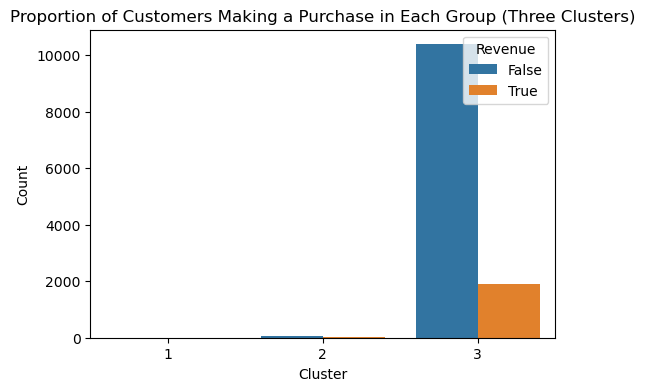

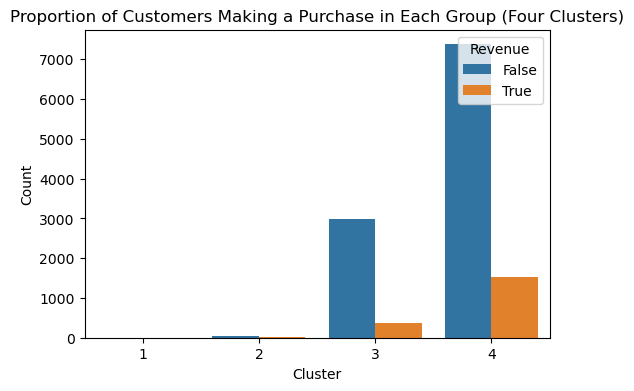

Percentual Cross-tabulation - Three Clusters:


cl3sters,Assiduous,Goal,Potential
Revenue,,,
False,73.33,100.0,84.58
True,26.67,0.0,15.42


In [8]:
########## CLUSTERS ANALYSIS ##########

plt.figure(figsize=(6, 4))
sns.countplot(data=df3, x='cl3sters', hue='Revenue')
plt.title('Proportion of Customers Making a Purchase in Each Group (Three Clusters)')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.legend(title='Revenue', loc='upper right', labels=['False', 'True'])
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(data=df3, x='cl4sters', hue='Revenue')
plt.title('Proportion of Customers Making a Purchase in Each Group (Four Clusters)')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.legend(title='Revenue', loc='upper right', labels=['False', 'True'])
plt.show()

df3['cl3sters'].replace({1: "Goal", 2: "Assiduous", 3: "Potential"}, inplace=True)
df3['cl4sters'].replace({1: "Goal", 2: "Assiduous", 3: "Potential", 4: "Promising"}, inplace=True)

cross_tab_3 = pd.crosstab(df3.Revenue, df3.cl3sters, normalize='columns') * 100
cross_tab_4 = pd.crosstab(df3.Revenue, df3.cl4sters, normalize='columns') * 100

print("Percentual Cross-tabulation - Three Clusters:")
cross_tab_3.round(2)

In [9]:
print("Percentual Cross-tabulation - Four Clusters:")
cross_tab_4.round(2)

Percentual Cross-tabulation - Four Clusters:


cl4sters,Assiduous,Goal,Potential,Promising
Revenue,,,,
False,73.33,100.0,89.15,82.85
True,26.67,0.0,10.85,17.15


## Results assessment

Evaluate the groups obtained in relation to variables outside the scope of the analysis (minimally *bounce rate* and *revenue*).
- Which group has customers most likely to purchase?

In [10]:
########## EVALUATION OF OUTSIDE VARIABLES ##########

def evaluate_revenue_and_bounce_rate(clusters, revenue, bounce_rate):
    cluster_df = pd.DataFrame({'Cluster': clusters, 'Revenue': revenue, 'BounceRate': bounce_rate})
    cluster_stats = cluster_df.groupby('Cluster')[['Revenue', 'BounceRate']].mean()
    print(round(cluster_stats * 100, 1))

print("- Percentual Analysis:")
evaluate_revenue_and_bounce_rate(df3['cl4sters'], df['Revenue'], df['BounceRates'])

- Percentual Analysis:
           Revenue  BounceRate
Cluster                       
Assiduous     26.7         3.4
Goal           0.0         0.4
Potential     10.9         2.7
Promising     17.1         2.0


> 'Assiduous' group is the most likely to purchase, that's why it's named like this.
>
> Even though it has the higher Bounce Rates, isn't that far from 'Potencial' & 'Promising' groups.

- 'Potencial' group aims for the cluster of second least buyers, meant to focus specialized marketing on them, creating a connection with them.

- 'Promising' are the clients that can be converted into 'Assiduous' with the right actions.

- 'Goal' group is actually the least buyers, that's why are the main targets of the study. Since 'Assiduous' are already into the product, we must put an extra effort into the 'Goal' cluster.